In [1]:
import timesfm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm 
import os 
from itertools import product
from collections import defaultdict
import time

from timesfm_functions import (
    TimesFMModel,
    load_aluminium_data,
    calculate_prediction_metrics,
)

from functions import line_plot, mape, mae, rmse, mse, mase, pred_value_to_char, find_n_best_features

 See https://github.com/google-research/timesfm/blob/master/README.md for updated APIs.


/home/panstenos/.pyenv/versions/3.11.10/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded PyTorch TimesFM, likely because python version is 3.11.10 (main, Aug 20 2025, 22:27:03) [GCC 13.3.0].


In [22]:
def get_batched_data_fn(df, batch_size, context_len, horizon_len, static=True):
    examples = defaultdict(list)
    sub_df = df.iloc[horizon_len:, :].reset_index(drop=True)
    N = len(sub_df)
    vol_col = f"{pred_value_to_char(horizon_len)}_vol"
    if vol_col not in sub_df.columns:
        raise KeyError(f"Column '{vol_col}' not found in sub_df")

    best_n_covariates = [
        c for c in find_n_best_features(expiry=horizon_len, n=20) if c in sub_df.columns
    ]

    for start in range(0, N - (context_len + horizon_len) + 1, 1):
        context_end = start + context_len

        examples["inputs"].append(sub_df[vol_col].iloc[start:context_end].to_list())

        if static:
            idx = context_end - 1
            for cov in best_n_covariates:
                examples[cov].append(float(sub_df[cov].iat[idx]))
        else:
            sl = slice(start, start + context_len)
            for cov in best_n_covariates:
                examples[cov].append(sub_df[cov].iloc[sl].to_list())

    num_examples = len(examples["inputs"])

    def data_fn():
        for i in range(0, num_examples, batch_size):
            yield {k: v[i:i + batch_size] for k, v in examples.items()}

    return data_fn

def _last_step(x):
    arr = np.asarray(x)
    if arr.ndim != 2:
        raise ValueError(f"Forecast must be 2D (batch, horizon), got {arr.shape}")
    return arr[:, -1].astype(float).tolist()

def run_inference(model, input_data, expiry, top_n, freq, static=True):
    vanilla_forecasts = []
    covariate_forecasts = []

    for i, example in tqdm(enumerate(input_data())):
        raw_forecast, _ = model.predict(
            inputs=example["inputs"], freq=[freq] * len(example["inputs"])
        )
        if static:
            cov_forecast, ols_forecast = model.predict_with_covariates(
                inputs=example["inputs"],
                dynamic_numerical_covariates={},
                dynamic_categorical_covariates={},
                static_numerical_covariates={
                    var: example[var] for var in find_n_best_features(expiry=expiry, n=top_n)
                },
                static_categorical_covariates={},
                freq=[freq] * len(example["inputs"]),
                xreg_mode="xreg + timesfm",
                ridge=0.0,
                force_on_cpu=False,
                normalize_xreg_target_per_input=True,
            )
        else:
            cov_forecast, ols_forecast = model.predict_with_covariates(
                inputs=example["inputs"],
                dynamic_numerical_covariates={
                    var: example[var] for var in find_n_best_features(expiry=expiry, n=top_n)
                },
                dynamic_categorical_covariates={},
                static_numerical_covariates={},
                static_categorical_covariates={},
                freq=[freq] * len(example["inputs"]),
                xreg_mode="xreg + timesfm",
                ridge=0.0,
                force_on_cpu=False,
                normalize_xreg_target_per_input=True,
            )

        vanilla_forecasts.extend(_last_step(raw_forecast))
        covariate_forecasts.extend(_last_step(cov_forecast))

    return vanilla_forecasts, covariate_forecasts

In [3]:
def get_cosine_data(n=2440):
    return pd.DataFrame({'1w_vol': np.cos(np.linspace(0, 2*np.pi, n, endpoint=False)).tolist()})

In [ ]:
df = load_aluminium_data()

batch_size = 64
context_len = 128
horizon_len = 5

In [5]:
model = TimesFMModel(expiry=horizon_len, context_length=context_len, positional_embedding=False)
input_data = get_batched_data_fn(df, batch_size = batch_size, context_len=context_len, horizon_len=horizon_len)

Fetching 5 files: 100%|██████████| 5/5 [00:00<00:00, 21642.44it/s]


In [23]:
vanilla_forecasts, covariate_forecasts = run_inference(model=model, input_data=input_data, expiry=5, top_n=5, freq=[1], static=True)

37it [00:15,  2.43it/s]


freq=0


37it [00:14,  2.61it/s]


freq=1


37it [00:13,  2.75it/s]


freq=2


37it [00:13,  2.66it/s]


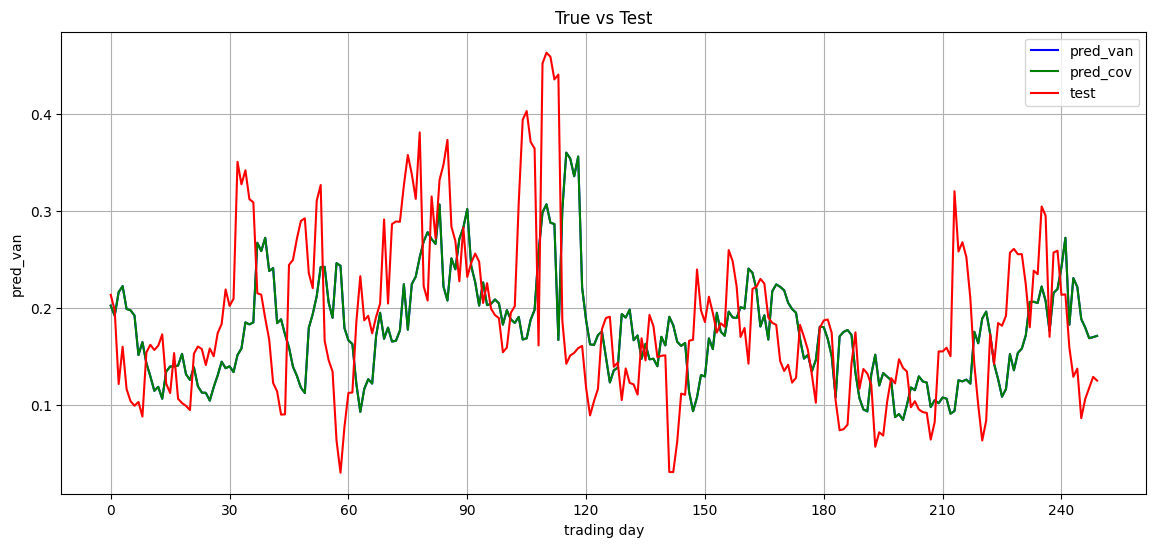

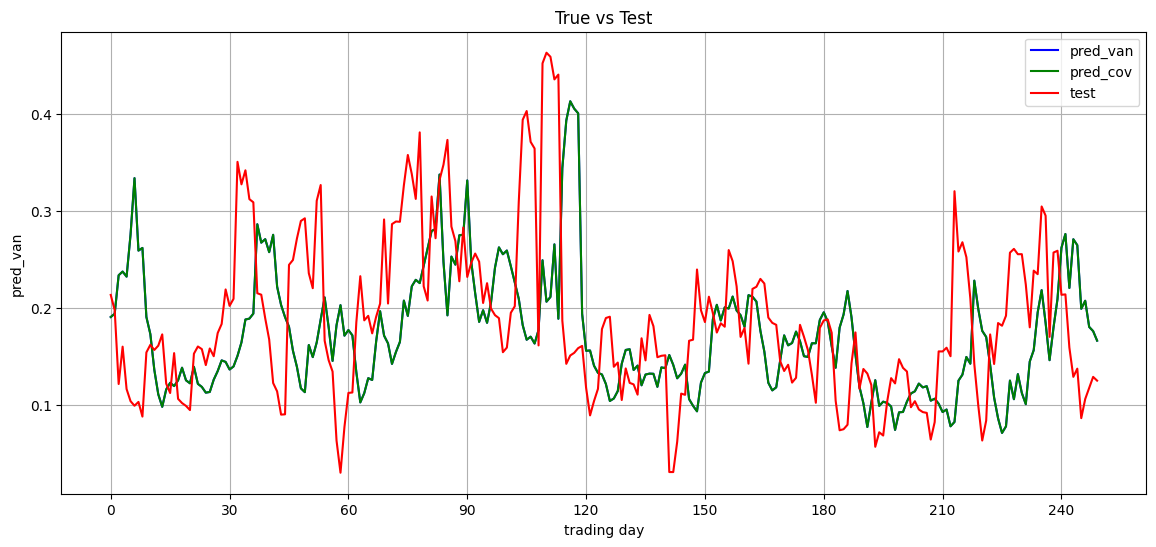

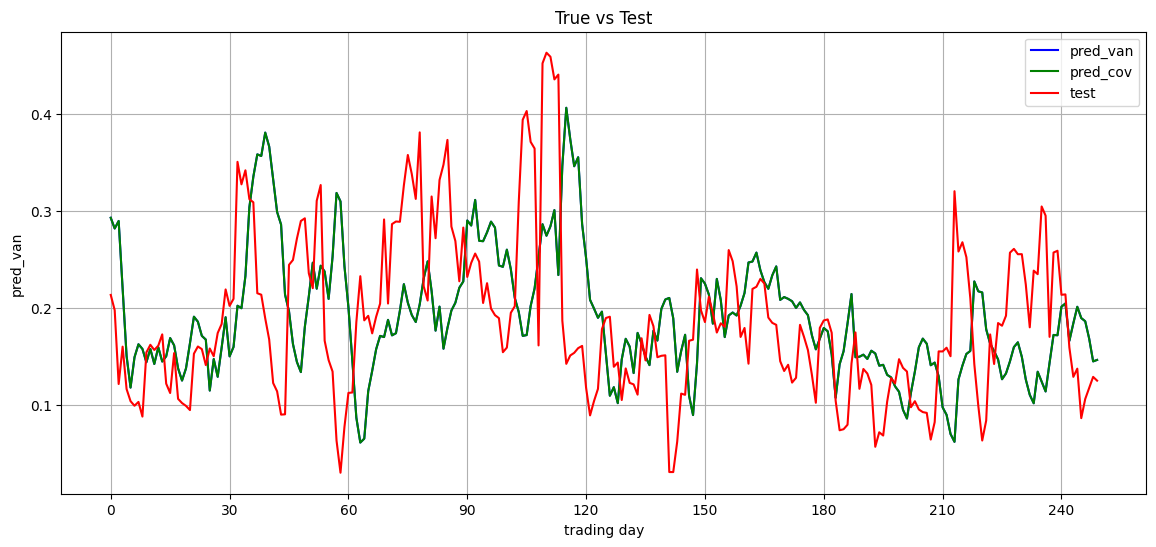

In [ ]:
for freq in [0, 1, 2]:
    print(f'freq={freq}')
    vanilla_forecasts, covariate_forecasts = run_inference(model=model, input_data=input_data, expiry=5, top_n=5, freq=freq, static=True)
    pred_van = vanilla_forecasts[-250:]
    pred_cov = covariate_forecasts[-250:]
    test_true = df[f'{pred_value_to_char(horizon_len)}_vol'][-250:].tolist()

    ax, fig = line_plot(pred_van, pred_van, 'pred_van', graphtitle='True vs Test', show=False)
    ax, fig = line_plot(pred_cov, pred_cov, 'pred_cov', ax=ax, linecolor='green', show=False)
    _, _ = line_plot(test_true, test_true, 'test', ax=ax, linecolor='red', show=True)

In [ ]:
cov_forecast = np.array(cov_forecast)
cov_forecast.shape

(64, 24)

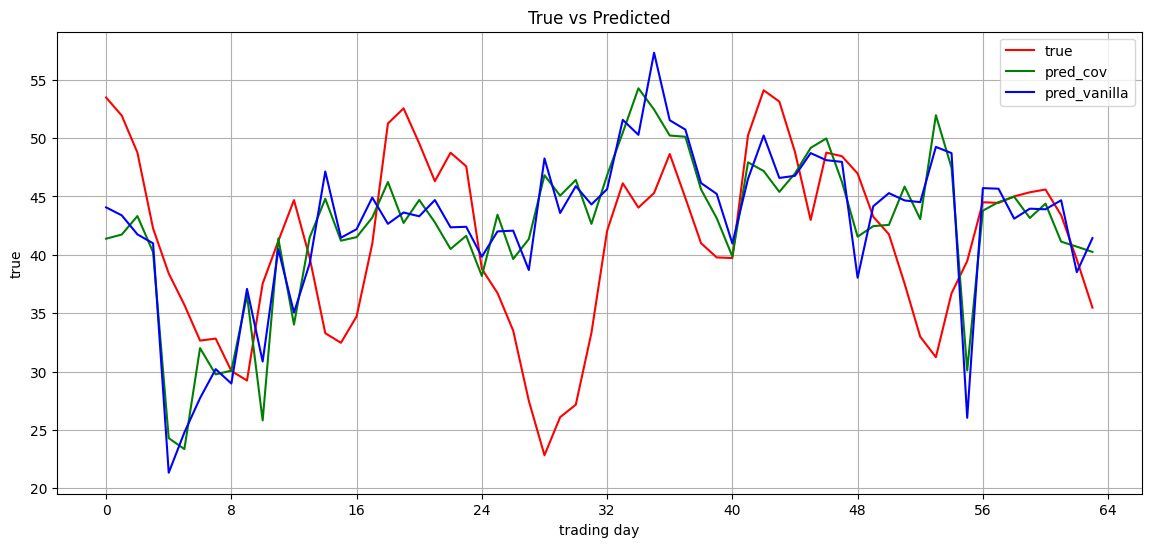

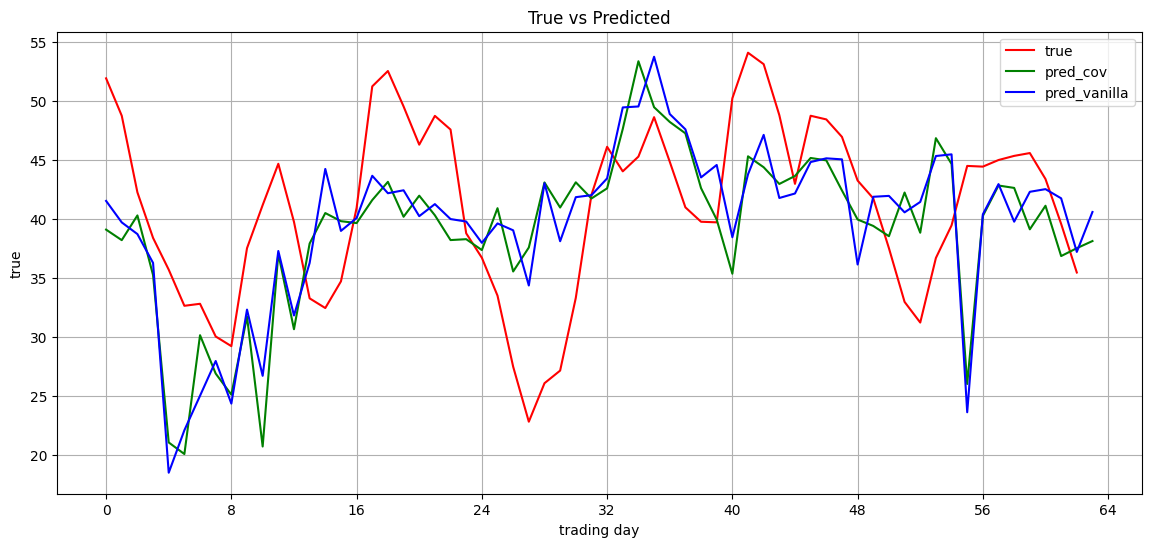

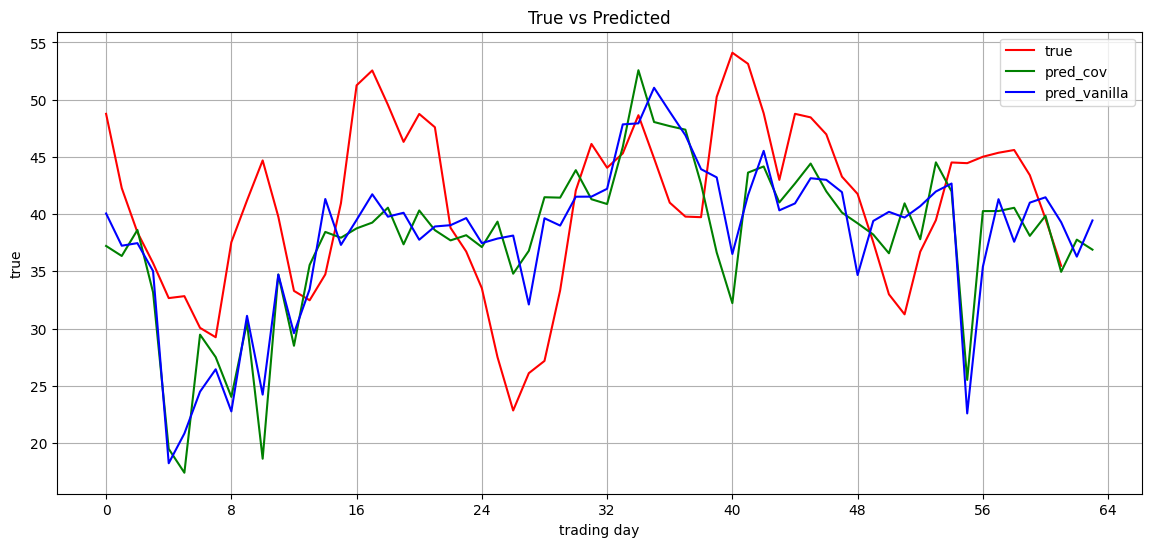

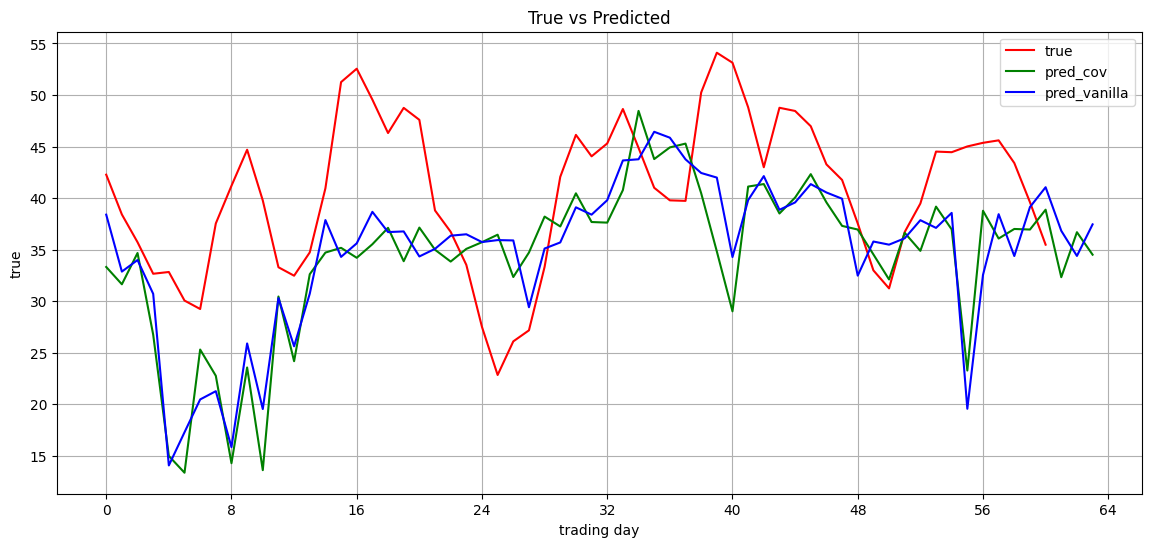

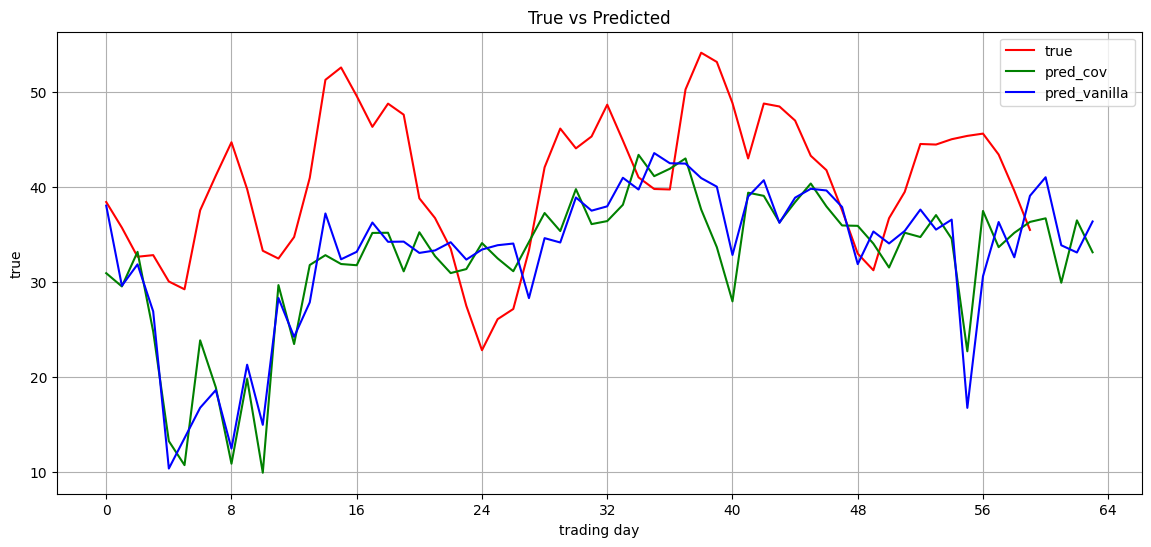

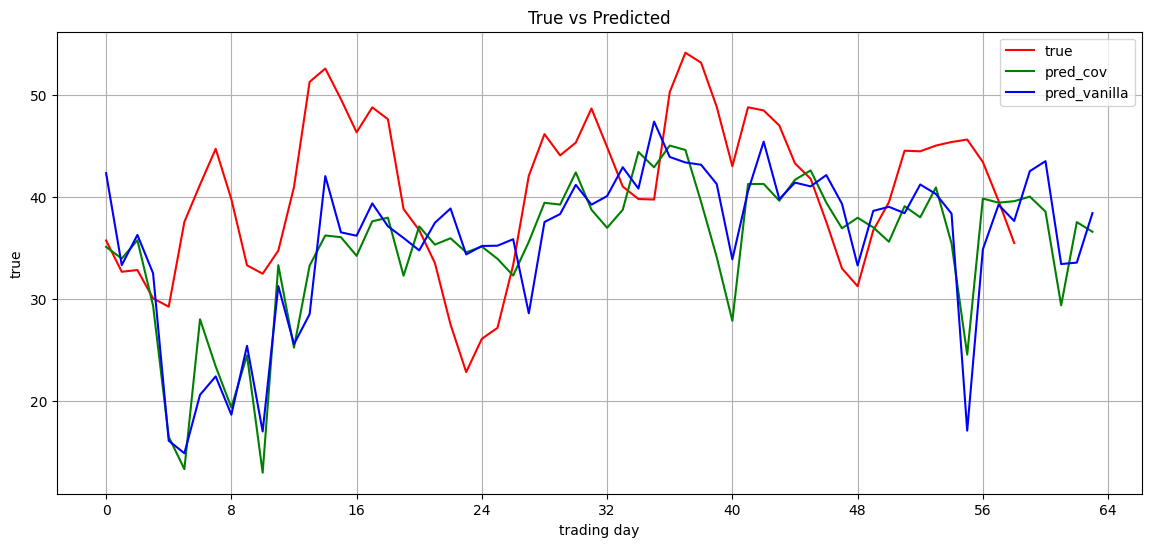

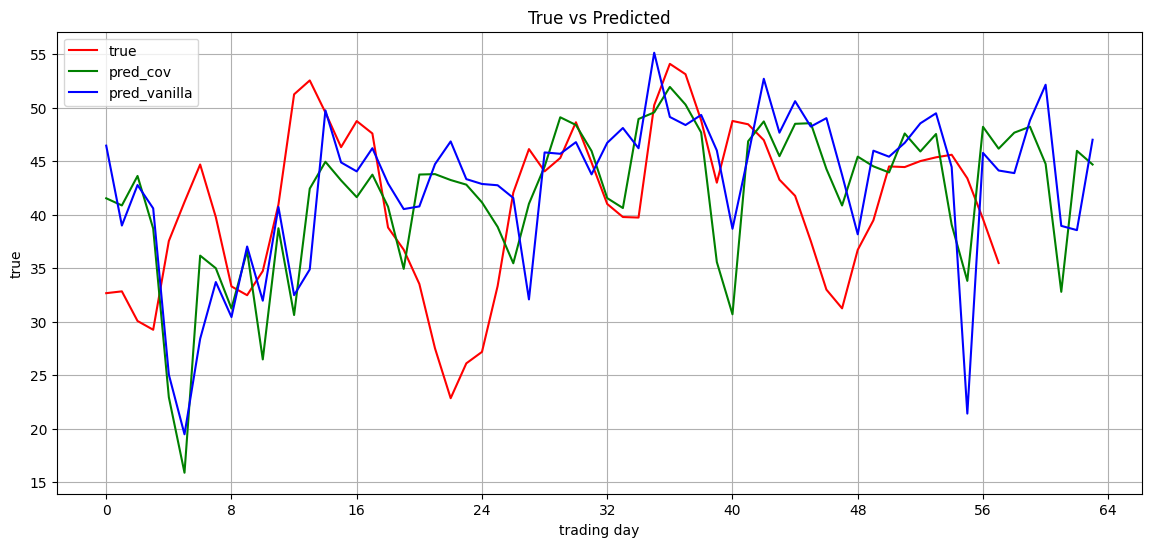

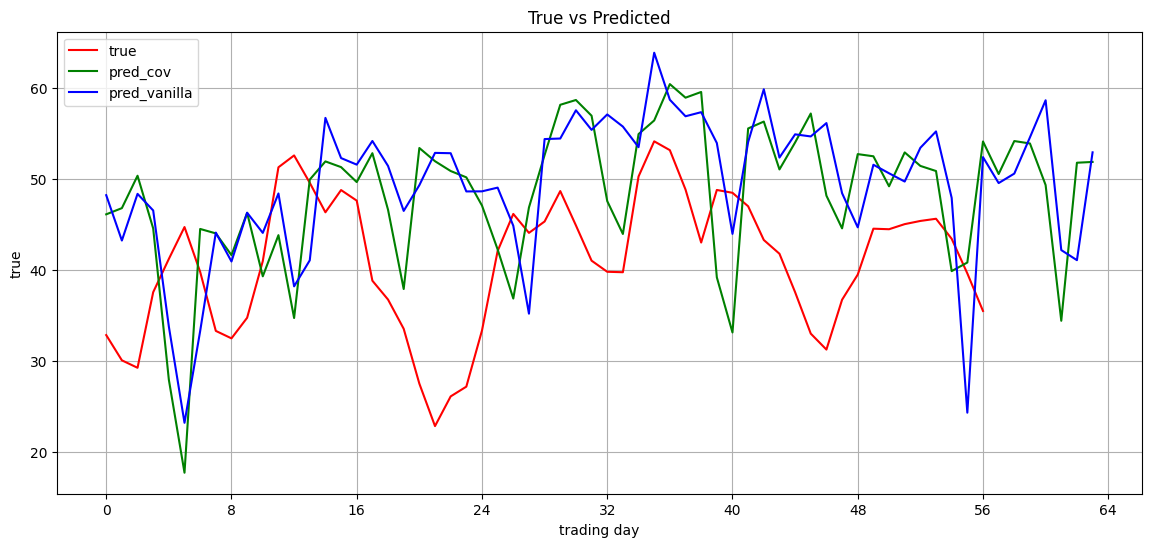

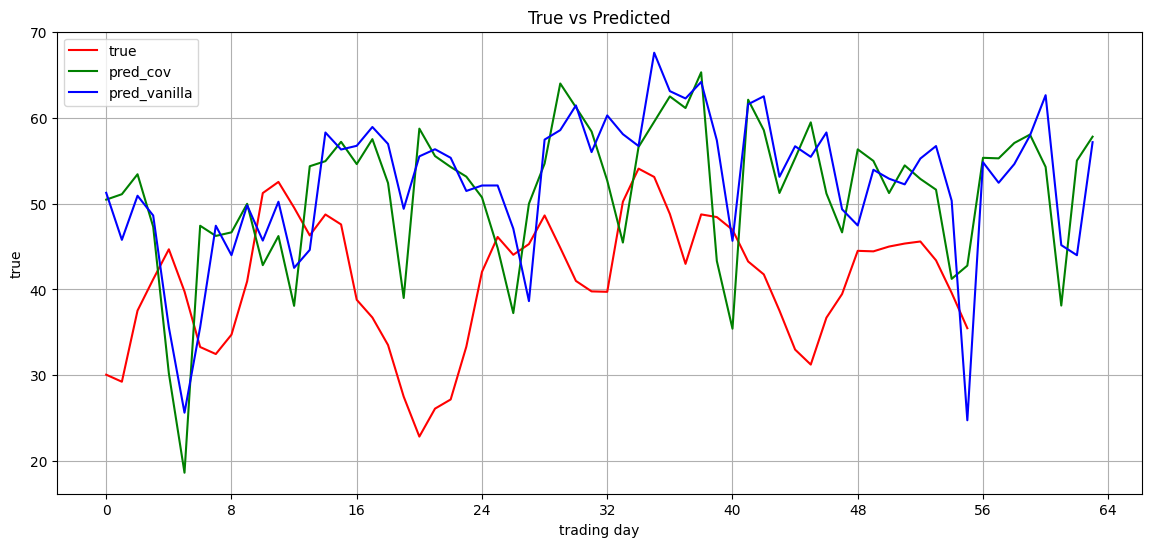

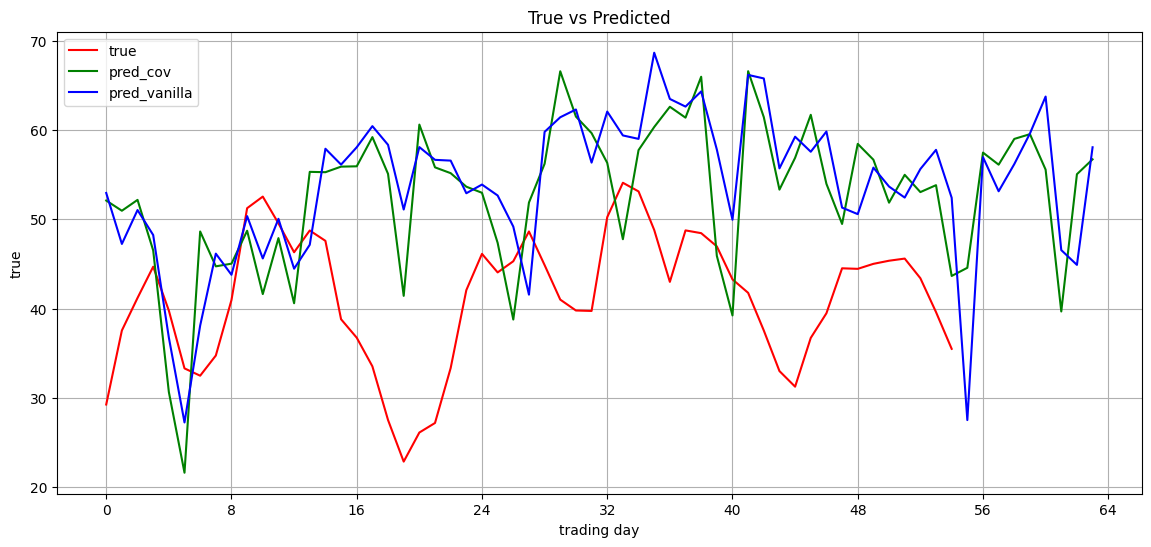

In [ ]:
for i in range(10):
    true = list(df['y'][i:len(raw_forecast)])
    pred = raw_forecast[i, :]
    pred_cov = cov_forecast[i, :]

    ax, fig = line_plot(true, true, 'true', graphtitle='True vs Predicted', linecolor='red', show=False)
    ax, fig = line_plot(pred_cov, pred_cov, 'pred_cov', linecolor='green', ax=ax, show=False)
    _, _ = line_plot(pred, pred, 'pred_vanilla', ax=ax, show=True)

In [ ]:
assert len(pred) == len(true),'pred and true arrays must be of the same length'

AssertionError: pred and true arrays must be of the same length

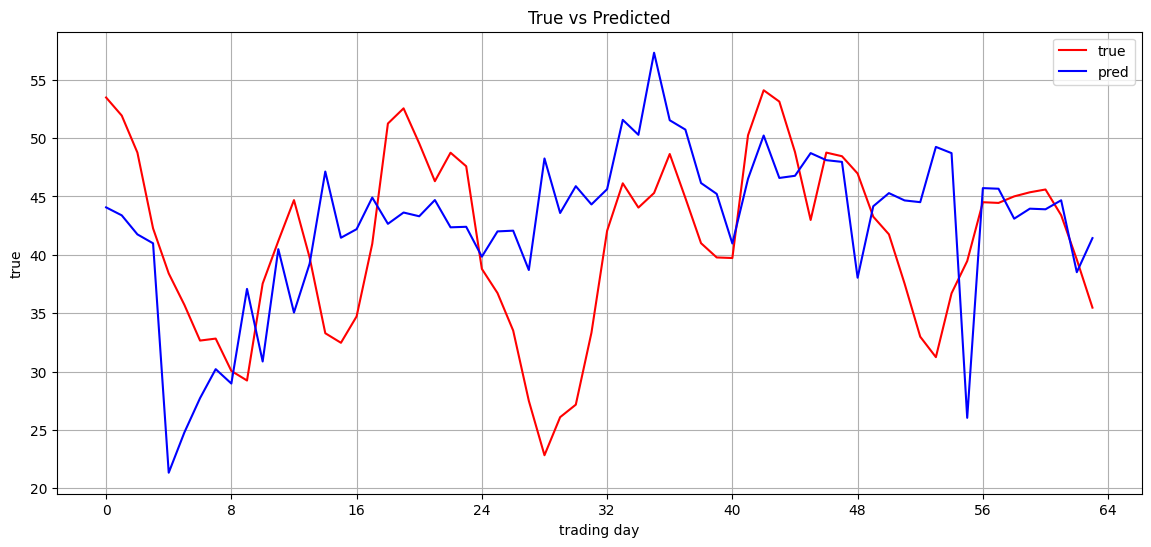

In [ ]:
ax, fig = line_plot(true, true, 'true', graphtitle='True vs Predicted', linecolor='red', show=False)
_, _ = line_plot(pred, pred, 'pred', ax=ax, show=True)

In [ ]:
raw_forecast[0]

array([44.06924 , 41.54515 , 40.05455 , 38.392235, 38.029934, 42.310318,
       46.451748, 48.18792 , 51.278275, 52.955093, 53.751595, 54.211975,
       54.723   , 53.775547, 53.010498, 51.776756, 52.77567 , 56.886497,
       59.11599 , 58.34228 , 57.41245 , 56.767403, 57.49266 , 57.828365,
       55.975746, 54.177326, 52.61036 , 50.82354 , 48.05642 , 47.65329 ,
       48.94874 , 48.437405, 49.858482, 50.25575 , 50.32537 , 51.070694,
       51.35559 , 49.934628, 48.533833, 47.145287, 47.62425 , 53.49623 ,
       56.10343 , 55.61473 , 55.36158 , 54.86376 , 54.860695, 54.469772,
       52.352997, 49.24785 , 47.32028 , 43.26828 , 40.01053 , 40.78453 ,
       42.21762 , 42.09406 , 44.67052 , 46.443348, 47.386547, 47.902412,
       49.31475 , 47.435543, 44.456795, 40.98573 , 40.8258  , 50.296253,
       53.49431 , 51.854687, 49.179207, 47.17827 , 47.67494 , 45.39557 ,
       41.44639 , 37.1886  , 33.59481 , 28.519598, 22.622242, 23.78965 ,
       26.533428, 28.723927, 34.27128 , 36.474335, 

In [ ]:
toy_input_pipeline = get_batched_data_fn(batch_size=2, context_len=5, horizon_len=2)
print(next(toy_input_pipeline()))

{'country': ['FR', 'FR'], 'inputs': [[53.48, 51.93, 48.76, 42.27, 38.41], [48.76, 42.27, 38.41, 35.72, 32.66]], 'gen_forecast': [[76905.0, 75492.0, 74394.0, 72639.0, 69347.0, 67960.0, 67564.0], [74394.0, 72639.0, 69347.0, 67960.0, 67564.0, 67277.0, 67019.0]], 'week_day': [[3, 3, 3, 3, 3, 3, 3], [3, 3, 3, 3, 3, 3, 3]], 'outputs': [[35.72, 32.66], [32.83, 30.06]]}


In [ ]:
print(mse(y_true, y_pred_vanilla))
print(mse(y_true, y_pred_xreg))

213.22094946865855
287.0999252680654


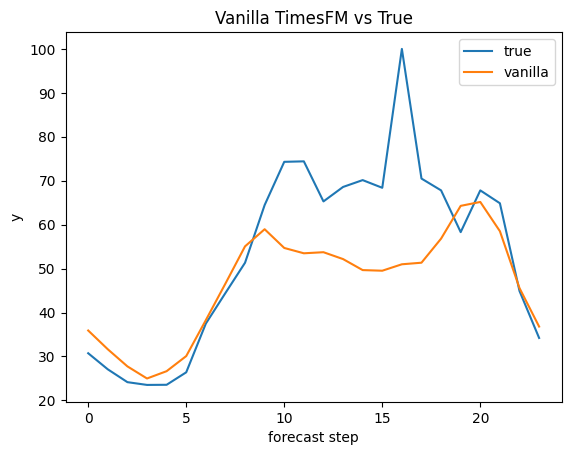

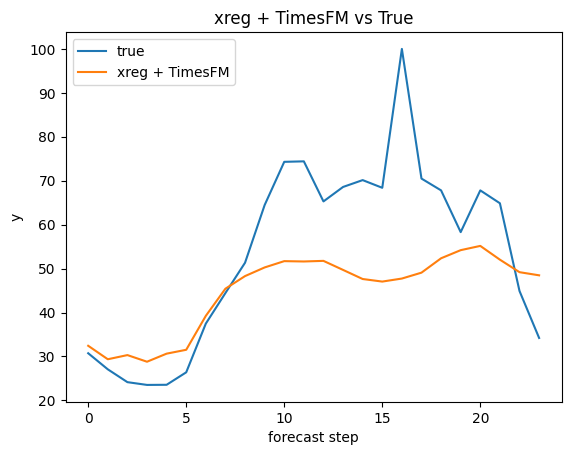

In [ ]:
series_idx = 0

# ensure arrays
y_true = np.asarray(example["outputs"][series_idx])                # shape [horizon_len]
y_pred_vanilla = np.asarray(raw_forecast[series_idx, :horizon_len])# shape [horizon_len]
y_pred_xreg = np.asarray(cov_forecast[series_idx])                 # shape [horizon_len]

x = np.arange(len(y_true))

# (a) vanilla TimesFM
plt.figure()
plt.plot(x, y_true, label="true")
plt.plot(x, y_pred_vanilla, label="vanilla")
plt.xlabel("forecast step")
plt.ylabel("y")
plt.title("Vanilla TimesFM vs True")
plt.legend()
plt.show()

# (b) xreg + TimesFM (with covariates)
plt.figure()
plt.plot(x, y_true, label="true")
plt.plot(x, y_pred_xreg, label="xreg + TimesFM")
plt.xlabel("forecast step")
plt.ylabel("y")
plt.title("xreg + TimesFM vs True")
plt.legend()
plt.show()
